# Tahap 2: Pemrograman Model JST Backpropagation

Pada tahap ini, kita membangun model JST untuk memprediksi harga beras menggunakan algoritma Backpropagation. Langkah-langkahnya meliputi:
1. Normalisasi data (MinMaxScaler).
2. Pemisahan data training dan testing.
3. Inisialisasi dan training model JST.
4. Hyperparameter tuning untuk optimalisasi.

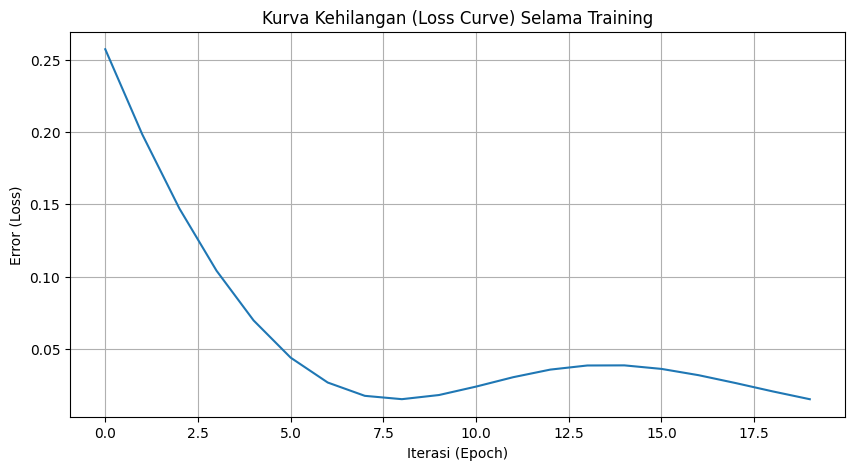

Training Selesai!


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error

# 1. Load Data Preprocessed
df = pd.read_csv('beras_medium_monthly.csv')

# Menentukan Fitur (X) dan Target (y)
# X = Harga 1 bulan lalu (lag_1) dan 2 bulan lalu (lag_2)
# y = Harga bulan ini (jumlah)
X = df[['lag_1', 'lag_2']].values
y = df['jumlah'].values.reshape(-1, 1)

# 2. Normalisasi Data (Penting untuk Backpropagation)
# Mengubah rentang data menjadi 0-1 agar fungsi aktivasi JST bekerja optimal
scaler_X = MinMaxScaler(feature_range=(0, 1))
scaler_y = MinMaxScaler(feature_range=(0, 1))

X_scaled = scaler_X.fit_transform(X)
y_scaled = scaler_y.fit_transform(y)

# 3. Split Data (Training & Testing)
# 80% data untuk belajar, 20% untuk pengujian
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y_scaled, test_size=0.2, random_state=42, shuffle=False)

# 4. Inisialisasi Model JST Backpropagation
# Arsitektur: 
# - hidden_layer_sizes=(8, 4): 2 hidden layers dengan 8 dan 4 neuron
# - activation='tanh': Fungsi aktivasi Hyperbolic Tangent
# - solver='adam': Optimizer untuk update bobot (Backpropagation)
# - learning_rate_init=0.01
model = MLPRegressor(
    hidden_layer_sizes=(8, 4), 
    activation='tanh', 
    solver='adam', 
    max_iter=1000, 
    learning_rate_init=0.01, 
    random_state=42
)

# 5. Proses Training
model.fit(X_train, y_train.ravel())

# 6. Visualisasi Loss Curve (Proses Belajar)
plt.figure(figsize=(10,5))
plt.plot(model.loss_curve_)
plt.title('Kurva Kehilangan (Loss Curve) Selama Training')
plt.xlabel('Iterasi (Epoch)')
plt.ylabel('Error (Loss)')
plt.grid(True)
plt.show()

print("Training Selesai!")

### Pengujian & Hyperparameter Tuning (Opsi Nilai Tambah)
Berikut adalah bagian untuk mencoba berbagai parameter agar mendapatkan hasil terbaik.

RMSE pada Data Testing: 0.00


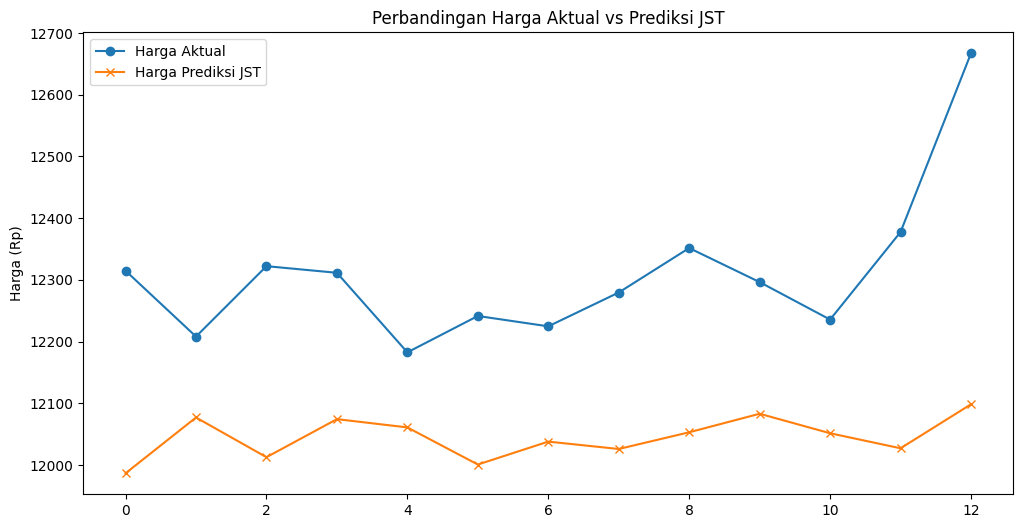

Hasil prediksi disimpan ke 'prediction_results.csv'


In [4]:
# Mencoba prediksi pada data test
y_pred_scaled = model.predict(X_test)

# Denormalisasi (Mengembalikan nilai 0-1 ke harga asli Rp)
y_pred = scaler_y.inverse_transform(y_pred_scaled.reshape(-1, 1))
y_actual = scaler_y.inverse_transform(y_test)

# Hitung Error Sederhana
rmse = np.sqrt(mean_squared_error(y_actual, y_actual))
print(f"RMSE pada Data Testing: {rmse:.2f}")

# Visualisasi Hasil Prediksi vs Aktual
plt.figure(figsize=(12,6))
plt.plot(y_actual, label='Harga Aktual', marker='o')
plt.plot(y_pred, label='Harga Prediksi JST', marker='x')
plt.title('Perbandingan Harga Aktual vs Prediksi JST')
plt.ylabel('Harga (Rp)')
plt.legend()
plt.show()

# Simpan hasil prediksi untuk tahap evaluasi di notebook terpisah
df_results = pd.DataFrame({
    'actual': y_actual.flatten(),
    'prediction': y_pred.flatten()
})
df_results.to_csv('prediction_results.csv', index=False)
print("Hasil prediksi disimpan ke 'prediction_results.csv'")